# Krittika Summer Projects 7.0: Computational Astronomy Assignment: Gravitational Lensing

This assignment explores the phenomenon of **gravitational lensing** through a sequence of computational and conceptual exercises. You will gradually build a working model simulation, beginning with classical optics and extending to relativistic light deflection by massive objects.

## Structure of the Assignment

The assignment is divided into multiple parts, each building on the previous one:

- (a) Classical thin lens optics  
- (b) Gravitational lensing: theory and derivation  
- (c) Simulation of lensing for a single point source  
- (d) Extension to extended sources  
- (e) Formation of Einstein rings  
- (f) Inverse problem: reconstruction of the source (graphically)
- (g) BONUS: Reconstruction of the source (bitmap image)

Each section introduces new ideas while reinforcing earlier ones. You are encouraged to move sequentially, but partial completion is fully acceptable.

## Expectations and Evaluation

This assignment is designed to prioritise **understanding over completion**.

- Partial attempts will be **valued and credited**
- Clear reasoning and explanation of your approach are important
- It is acceptable if some parts of the code do not fully work, as long as your thought process is evident

You should aim to:
- Show intermediate steps
- Explain assumptions or approximations
- Identify where difficulties arise

Submissions will be evaluated not only on correctness, but also on **clarity of reasoning and effort**.

## Role of Visualisation

A central component of this assignment is the use of **visualisation to understand physical systems**. You will use the Python library Matplotlib for all plotting tasks.

Visualisation is an essential tool in computational physics and is widely used in research contexts, including Krittika Summer Projects (KSPs). Producing clear, accurate, and interpretable plots is a fundamental skill.


## Matplotlib Guidelines

All plots in this assignment must be created using Matplotlib (refer https://matplotlib.org/stable/users/index.html for more information). For clarity and consistency, use small marker sizes while plotting points so that structure is not obscured:

```python
plt.scatter(x, y, s=3.5)
```
---


## Part (a): Classical Thin Lens Optics

Before moving to gravitational lensing, we begin with a familiar system from geometrical optics: the **thin convex lens**. This serves as an important conceptual and mathematical analogue for understanding how light rays are deflected and how images are formed.

In this part, you will analyse how a point source is imaged by a thin lens using both analytical expressions and graphical construction.

### Physical Setup

- Consider a **thin convex lens** placed along the vertical line \( x = 0 \), extending from \( y = -1.5 \) to \( y = +1.5 \).
- The lens has a **focal length** \( f = 1 \) (in arbitrary units).
- A point source is located at coordinates \( (x_0, y_0) \).


#### (i) Analytical Image Formation

- Given a point \( (x_0, y_0) \) (take user input as a floating point), compute the image position \( (x', y') \)
- Carefully consider and handle all possible cases.


#### (ii) Ray Diagram Construction

You will then construct a **graphical ray diagram** using Matplotlib:

- Draw a **horizontal incident ray** from the point source to the lens
- Show how this ray is refracted by the lens


Enter coordinates of point source (x,y): -2,1
Image coordinates: (2.00, -1.00)


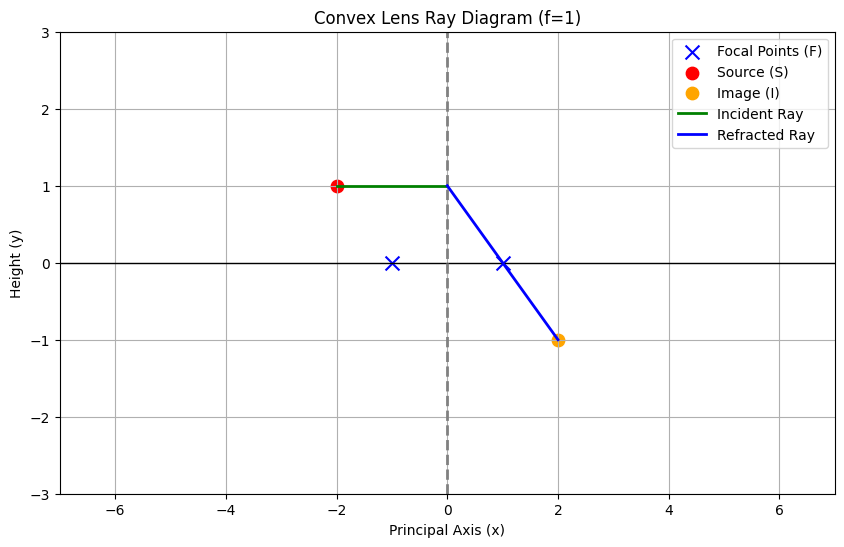

In [32]:
import matplotlib.pyplot as plt
import numpy as np

source= input("Enter coordinates of point source (x,y): ")
xs, ys= (float(i) for i in source.split(","))
f=1
lens_x=0
lens_y=1.5

if ys <= lens_y and ys >= -lens_y:
  if abs(xs+f) < 1e-9:
    print("The source is at the focal point. Image is at infinity.")
    xi, yi = None, None
  elif xs==0:
    print(f"The source is at the lens. Image is at (0, {ys})")
  else:
    xi= (xs*f) / (xs+f)
    yi = ys* (xi / xs)
    print(f"Image coordinates: ({xi:.2f}, {yi:.2f})")

  if xi is not None:
      # --- RAY DIAGRAM ---
      # DRAWING THE PRINCIPAL AXIS
      fig, ax = plt.figure(figsize=(10, 6)), plt.gca()
      plt.axhline(0, color='black', linewidth=1) # Principal axis
      plt.axvline(lens_x, color='gray', linestyle='--', linewidth=2) # Represents the lens

      # LOCATING FOCUS, SOURCE, IMAGE
      plt.scatter([-f, f], [0, 0], color='blue', marker='x', s=100, label='Focal Points (F)')
      plt.scatter(xs, ys, color='red', s=80, label='Source (S)')
      plt.scatter(xi, yi, color='orange', s=80, label='Image (I)')

      # INCIDENT RAY
      plt.plot([xs, lens_x], [ys, ys], color='green', linewidth=2, label='Incident Ray')

      # REFRACTED RAY
      plt.plot([lens_x, xi], [ys, yi], color='blue', linewidth=2, label='Refracted Ray')

      # LABELLING THE PLOT
      plt.title(f'Convex Lens Ray Diagram (f={f})')
      plt.xlabel('Principal Axis (x)')
      plt.ylabel('Height (y)')
      plt.legend()
      plt.grid(True)

      # PLOT LIMITS FOR CLARITY
      plt.xlim(min(xs, -f, xi)-5, max(xs, f, xi)+5)
      plt.ylim(min(ys, yi)-2, max(ys, yi)+2)

      plt.show()

else:
    print("Ray will not intersect the lens.")



## Part (b): Gravitational Lensing — Theory

In this part, you will study how a massive object bends light and produces multiple images of a source.

![Gravitational Lensing Diagram](https://raw.githubusercontent.com/AT-2517/KSP7.0_Selection_Assignment/0b3c4e750f8e8473750b947bc84eb1a49259c091/Computational_Astronomy/Grav_Lensing_Diagram.png)

### Key Relations

Deflection angle:
$$
\tilde{\alpha} = \frac{4GM}{c^2 \xi}, \quad \xi = d_L \tan\theta
$$

Lens equation:
$$
\theta = \beta + \frac{d_{LS}}{d_S}\tilde{\alpha}
$$

Einstein angle:
$$
\theta_E = \sqrt{\frac{4GM}{c^2}\frac{d_{LS}}{d_L d_S}}
$$


### Task

- Solve the **exact equation** numerically  
- Find an approximate equation for situations $\theta_E$ is small. Solve the **approximate equation** analytically.
- Compute and plot the **percentage error** vs $\,\beta / \theta_E\,$  Identify the breakaway point where the error starts growing out of bounds.

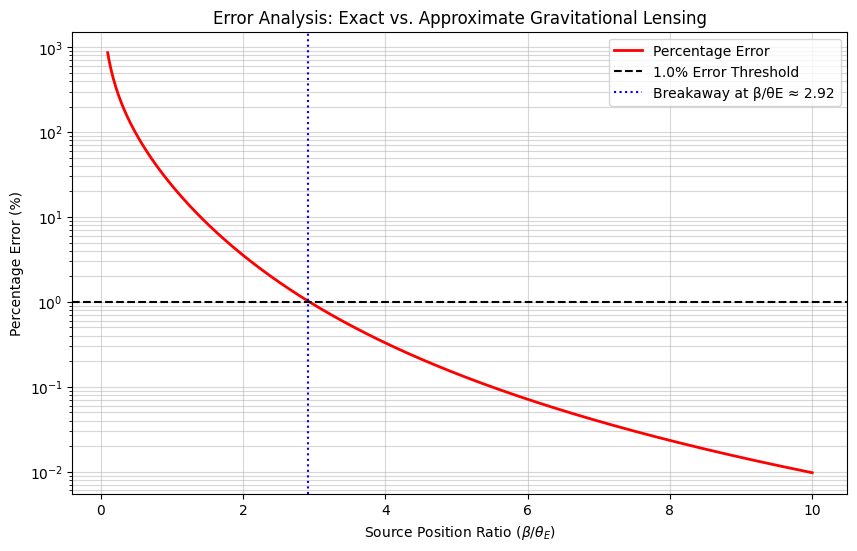

The approximation breaks away (exceeds 1.0%) at beta/theta_E (approx.) = 2.92


In [18]:
import numpy as np
import matplotlib.pyplot as plt

def solve_exact(beta, theta_E):
    # solving the quadratic equation
    theta_plus = (beta + np.sqrt(beta**2 + 4 * theta_E**2)) / 2
    theta_minus = (beta - np.sqrt(beta**2 + 4 * theta_E**2)) / 2
    return theta_plus

def solve_approx(beta, theta_E):
    # for small theta: derived using taylor expansion
    return beta + (theta_E**2 / beta)

theta_E = 1.0  # considering constant
# Range of beta/theta_E from 0.1 (very close) to 10 (far away)
ratios = np.linspace(0.1, 10, 500)
beta_values = ratios * theta_E

# storing the solutions
exact_vals = np.array([solve_exact(b, theta_E) for b in beta_values])
approx_vals = np.array([solve_approx(b, theta_E) for b in beta_values])

# calculating percentage error
# Formula: |(Exact - Approx) / Exact| * 100
percent_error = np.abs((exact_vals - approx_vals) / exact_vals) * 100

# break point (i am defining it as when error exceeds 1%)
threshold = 1.0
breakaway_idx = np.where(percent_error > threshold)[0][-1]
breakaway_ratio = ratios[breakaway_idx]

# graph
plt.figure(figsize=(10, 6))
plt.plot(ratios, percent_error, label='Percentage Error', color='red', lw=2)

# breakaway point
plt.axhline(y=threshold, color='black', linestyle='--', label=f'{threshold}% Error Threshold')
plt.axvline(x=breakaway_ratio, color='blue', linestyle=':', label=f'Breakaway at β/θE ≈ {breakaway_ratio:.2f}')

plt.title('Error Analysis: Exact vs. Approximate Gravitational Lensing')
plt.xlabel(r'Source Position Ratio ($\beta / \theta_E$)')
plt.ylabel('Percentage Error (%)')
plt.yscale('log') # could not clearly differentiate in normal scale
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.show()

print(f"The approximation breaks away (exceeds {threshold}%) at beta/theta_E (approx.) = {breakaway_ratio:.2f}")

## Part (c): Simulation of a Single Lensed Point Source

In this part, you will simulate gravitational lensing of a **single point source** by a massive object placed at the origin.

Assume the following constants (fixed for the simulation):
$$
d_L = 5.00 \times 10^{11}\,\text{m}, \quad
d_S = 9.75 \times 10^{17}\,\text{m}, \quad
d_{LS} = 9.75 \times 10^{17}\,\text{m}
$$

Using these, compute the Einstein angle:
$$
\theta_E = \sqrt{\frac{4GM}{c^2} \cdot \frac{d_{LS}}{d_L d_S}}
$$

### Task

Given a source position $S = (x, y)$:
-Plot:
   - Source point
   - Image(s)
   - Lens at origin

### Cases to Explore

(i) Source on x/y axis (aligned cases)

(ii) Source off-axis (general cases)

---

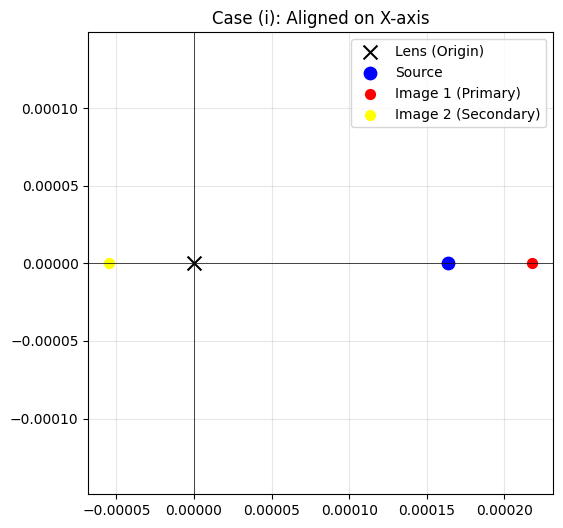

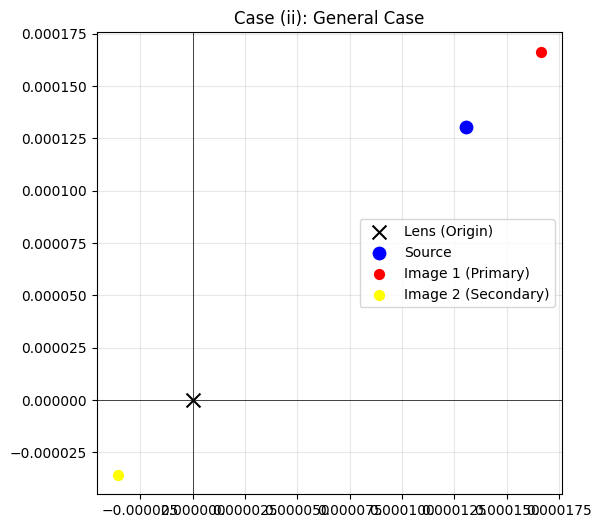

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.674e-11
c = 3.0e8
M = 2.0e30  # Mass of the lens
dL = 5.00e11
dS = 9.75e17
dLS = 9.75e17

# Einstein Angle
theta_E = np.sqrt((4 * G * M / c**2) * (dLS / (dL * dS)))

def get_images(x, y, theta_E):
    # beta is the angular separation of source from lens center
    beta = np.sqrt(x**2 + y**2)

    if beta == 0:
        return None

    # solution of quadratic: theta^2 - beta*theta - theta_E^2 = 0
    t1 = (beta + np.sqrt(beta**2 + 4*theta_E**2)) / 2
    t2 = (beta - np.sqrt(beta**2 + 4*theta_E**2)) / 2

    # unit direction vector
    ux, uy = x/beta, y/beta

    # Image coordinates
    img1 = (t1 * ux, t1 * uy)
    img2 = (t2 * ux, t2 * uy)

    return img1, img2

# --- Plotting graph ---
def plot_lensing(sx, sy, theta_E, title):
    imgs = get_images(sx, sy, theta_E)

    plt.figure(figsize=(6,6))
    # Plot Lens
    plt.scatter(0, 0, color='black', marker='x', s=100, label='Lens (Origin)')

    # Plot Source
    plt.scatter(sx, sy, color='blue', s=80, label='Source')

    # Plot Images
    if imgs:
        i1, i2 = imgs
        plt.scatter(i1[0], i1[1], color='red', s=50, label='Image 1 (Primary)')
        plt.scatter(i2[0], i2[1], color='yellow', s=50, label='Image 2 (Secondary)')

    plt.axhline(0, color='black', lw=0.5); plt.axvline(0, color='black', lw=0.5)
    plt.title(title)
    plt.legend()
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Cases ---

# (i) Aligned case (on x-axis)
plot_lensing(sx=1.5*theta_E, sy=0, theta_E=theta_E, title="Case (i): Aligned on X-axis")

# (ii) General case (off-axis)
plot_lensing(sx=1.2*theta_E, sy=1.2*theta_E, theta_E=theta_E, title="Case (ii): General Case")

## Part (d): Extended Sources

In this part, you will extend your simulation from a single point source to an **extended source**, modelled as a collection of multiple points.

Assume the source is a small circular region centred at $(x_0, y_0)$ with radius $R$. This can be approximated by sampling many points within the circle.

### Task
Plot:
   - Original source points (blue, small markers)
   - Corresponding lensed image points (red/yellow)

### Suggested Parameters

- Number of points: 150–300  

### Notes

- Use very small marker sizes ($s \leq 5$) for clarity  
- You should observe distortion of the circular source near alignment  
- You can plot both source points and image points on the same plane by considering angular variation only (i.e., plotting the points in terms of $\theta_x$ and $\theta_y$, where $\theta_x$, $\theta_y$ represent the angular separation from the source in the x and y directions).

---

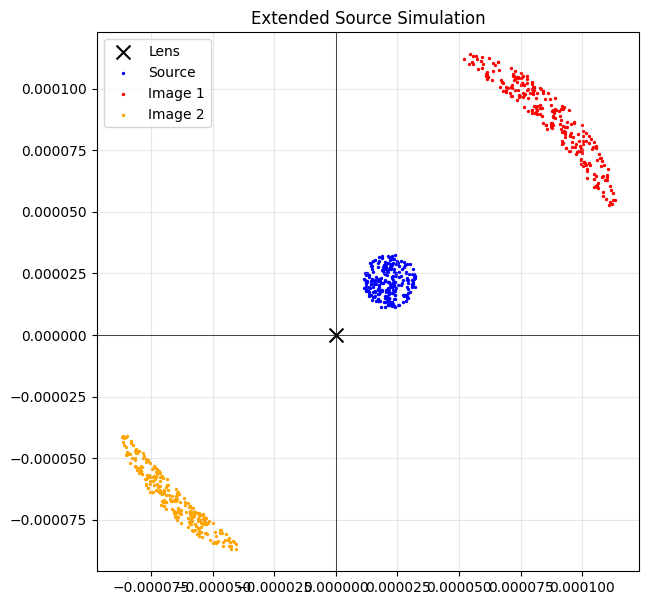

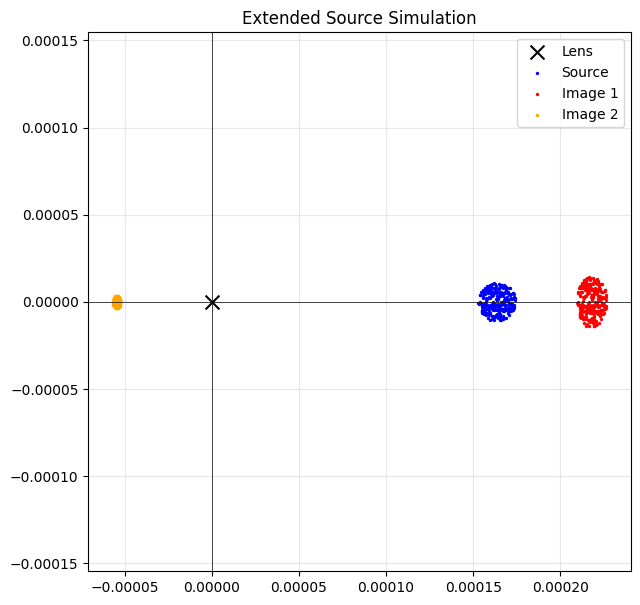

In [29]:
# for this part, only an additional function to last part is needed,
# function plot_extended_source is defined which make extended sources in circular pattern using polar coordinates

import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.674e-11
c = 3.0e8
M = 2.0e30
dL = 5.00e11
dS = 9.75e17
dLS = 9.75e17

# Einstein Angle
theta_E = np.sqrt((4 * G * M / c**2) * (dLS / (dL * dS)))

def get_images(x, y, theta_E):
    # beta is the angular separation of source from lens center
    beta = np.sqrt(x**2 + y**2)
    if beta == 0:
        return None

    # solution of quadratic: theta^2 - beta*theta - theta_E^2 = 0
    t1 = (beta + np.sqrt(beta**2 + 4*theta_E**2)) / 2
    t2 = (beta - np.sqrt(beta**2 + 4*theta_E**2)) / 2

    # unit direction vector
    ux, uy = x/beta, y/beta

    # Image coordinates
    img1 = (t1 * ux, t1 * uy)
    img2 = (t2 * ux, t2 * uy)
    return img1, img2

def plot_extended_source(x0, y0, R, n_points=250):
    # Generate points within a circular region
    r = R * np.sqrt(np.random.rand(n_points))
    phi = 2 * np.pi * np.random.rand(n_points)

    source_xs = x0 + r * np.cos(phi)
    source_ys = y0 + r * np.sin(phi)

    i1x, i1y = [], []
    i2x, i2y = [], []

    for sx, sy in zip(source_xs, source_ys):
        res = get_images(sx, sy, theta_E)
        if res:
            p1, p2 = res
            i1x.append(p1[0])
            i1y.append(p1[1])
            i2x.append(p2[0])
            i2y.append(p2[1])

    # --- Plotting graph ---
    plt.figure(figsize=(7,7))

    # Plot Lens
    plt.scatter(0, 0, color='black', marker='x', s=100, label='Lens')

    # Plot Original source points
    plt.scatter(source_xs, source_ys, color='blue', s=2, label='Source')

    # Plot Corresponding lensed image points
    plt.scatter(i1x, i1y, color='red', s=2, label='Image 1')
    plt.scatter(i2x, i2y, color='orange', s=2, label='Image 2')

    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.title("Extended Source Simulation")
    plt.legend()
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Cases ---

# (i) Source near alignment
R_val = 0.1 * theta_E
plot_extended_source(x0=0.2*theta_E, y0=0.2*theta_E, R=R_val)

# (ii) Source off-axis
plot_extended_source(x0=1.5*theta_E, y0=0, R=R_val)

## Part (e): Formation of an Einstein Ring

In this part, you will study how an **Einstein ring** forms as the source becomes increasingly aligned with the lens.

### Task

1. Consider a point source located along the vertical axis:
   $$
   S = (0, y)
   $$

2. Choose a sequence of source positions approaching perfect source-lens alignment along vertical axis.

3. Create **five separate plots**, one for each value of $y$:
   - Plot the source (blue)
   - Plot both image positions (red/yellow)
   - Plot the lens at the origin (black)

### Notes
- Ensure consistent axis limits across all plots for comparison  


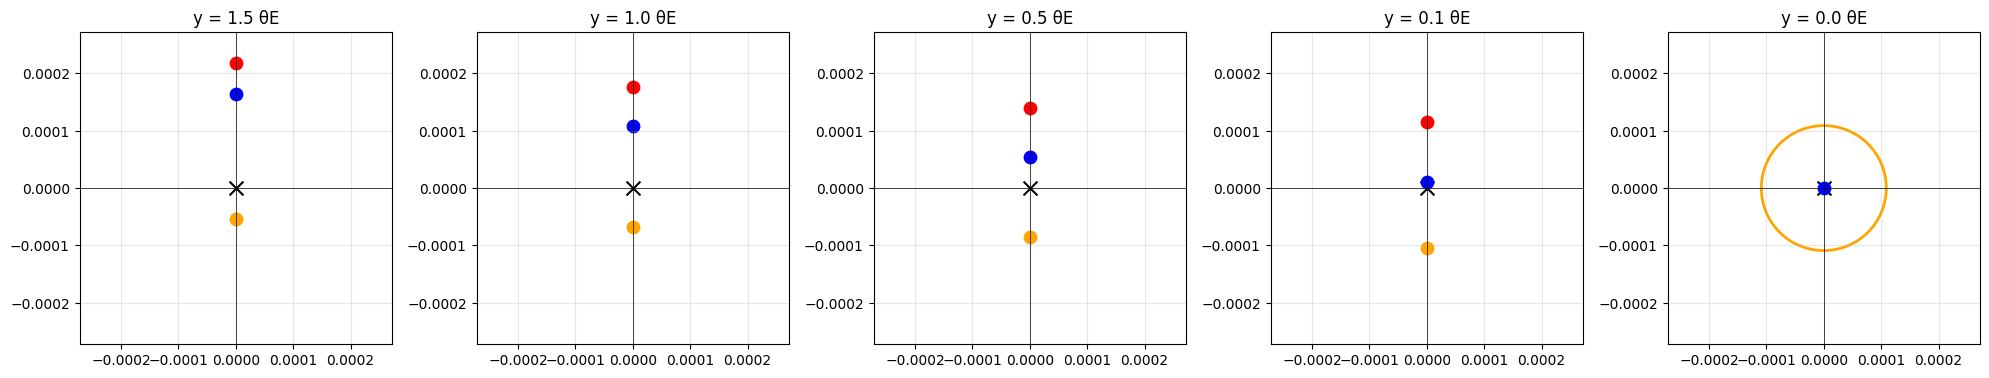

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.674e-11
c = 3.0e8
M = 2.0e30
dL = 5.00e11
dS = 9.75e17
dLS = 9.75e17

# Einstein Angle
theta_E = np.sqrt((4 * G * M / c**2) * (dLS / (dL * dS)))

def get_images(x, y, theta_E):
    beta = np.sqrt(x**2 + y**2)

    # perfect alignment for the ring case
    if beta < 1e-15:
        return None

    t1 = (beta + np.sqrt(beta**2 + 4*theta_E**2)) / 2
    t2 = (beta - np.sqrt(beta**2 + 4*theta_E**2)) / 2

    ux, uy = x/beta, y/beta

    img1 = (t1 * ux, t1 * uy)
    img2 = (t2 * ux, t2 * uy)
    return img1, img2

# Sequence of y positions approaching zero
y_positions = [1.5*theta_E, 1.0*theta_E, 0.5*theta_E, 0.1*theta_E, 0.0]

# --- Plotting graph ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, y_pos in enumerate(y_positions):
    ax = axes[i]

    # Plot Lens
    ax.scatter(0, 0, color='black', marker='x', s=100, label='Lens')

    # Plot Source
    ax.scatter(0, y_pos, color='blue', s=80, label='Source')

    # Plot Images
    res = get_images(0, y_pos, theta_E)

    if res:
        p1, p2 = res
        ax.scatter(p1[0], p1[1], color='red', s=80, label='Image 1')
        ax.scatter(p2[0], p2[1], color='orange', s=80, label='Image 2')
    else:
        # Special case: Plotting the Einstein Ring
        ring = plt.Circle((0, 0), theta_E, color='orange', fill=False, lw=2, label='Einstein Ring')
        ax.add_patch(ring)

    # Consistent axis limits
    limit = 2.5 * theta_E
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(f"y = {y_pos/theta_E:.1f} θE")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Part (f): Original Image Reconstruction from Lensed Image

For this part, you are provided a set of points, that represents the lensed image of a celestial body. The coordinates of the lens are given to be (0, 0).
Use the provided [lensed_points.csv](https://github.com/krittikaiitb/KSP-7.0-Selection-Assignment/blob/master/Coding%20Assignment/lensed_points.csv)
###Task:

1. Derive the inverse transformation to find the set of coordinates corresponding to the original image.
2. Consider a celestial object represented by the set of coordinates in the .csv file. These represent the coordinates in the normalised angular space (i.e. in terms of $\theta_x/\theta_E$ and $\theta_y/\theta_E$).
3. Use the derived transformation to find the set of coordinates for the actual image. Plot it, using a suitable scale.

##Part (g): Bonus Question
You are provided with an actual 24-bit bitmap image ([hubble-lrg3757.bmp](https://github.com/krittikaiitb/KSP-7.0-Selection-Assignment/blob/master/Coding%20Assignment/hubble-lrg3757.bmp)) of a lensed galaxy, a nearly perfect Einstein Ring (Source: [NASA - LRG 3-757](https://science.nasa.gov/image-detail/einstein-ring-lrg-3-757/)). Use the transformation derived earlier and find the actual, de-lensed image of the galaxy (what the galaxy would look like if the original foreground cluster were not present).
![LRG 3-757](https://raw.githubusercontent.com/AT-2517/KSP7.0_Selection_Assignment/refs/heads/main/Computational_Astronomy/hubble-lrg3757.bmp)
###Task:
1. Import the image as a NumPy array. (Convert to Grayscale if necessary)
2. Write a script to map the pixels of the lensed image back to their source positions, You may have to crop the image suitably, use thresholding to identify bright regions of the image. You may refer to the OpenCV documentation here:- https://docs.opencv.org/4.x/index.html
3. Use $d_L$ = 6.3 $\times$ $10^9$ light years, $d_S$ = 10.9 $\times$ $10^9$ light years (refer to the diagram for the notation).

##